In [1]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.features import shapes
import numpy as np
import geopandas as gpd
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
import torch
import tqdm

In [6]:
predictions_rst = "/mnt/sdd/ls789gf/{}_silver_sweep_9_102022.vrt"
area_shp = "/mnt/sdc/tree_density_and_coverage/shapefiles/nasa_validation/senegal_cutlines_intersection_with_tiles_sorted_squares_960m_joined.gpkg"
early_dir = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/rasters_early"
late_dir = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/rasters_late"

In [5]:
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import tqdm

# --- Parameters ---
square_size = 960  # meters
input_file = area_shp
output_file = area_shp.replace(".gpkg", f"_squares_{square_size}m.gpkg")

# --- Load polygons ---
gdf = gpd.read_file(input_file)

# Reproject to a metric CRS (e.g. UTM zone appropriate for your area)
# If already in meters, you can skip this step
gdf = gdf.to_crs(gdf.estimate_utm_crs())

all_squares = []

# --- Iterate polygons ---
for idx, poly in tqdm.tqdm(gdf.iterrows(), total=len(gdf)):
    bounds = poly.geometry.bounds  # (minx, miny, maxx, maxy)

    minx, miny, maxx, maxy = bounds

    # Create grid coordinates
    x_coords = np.arange(minx, maxx, square_size)
    y_coords = np.arange(miny, maxy, square_size)

    for x in x_coords:
        for y in y_coords:
            square = box(x, y, x + square_size, y + square_size)
            # Keep only squares fully inside polygon
            if square.within(poly.geometry):
                all_squares.append({"geometry": square, "parent_id": idx})

# --- Save to GeoDataFrame ---
squares_gdf = gpd.GeoDataFrame(all_squares, crs=gdf.crs)
squares_gdf.to_file(output_file)

print(f"✅ Created {len(squares_gdf)} square polygons inside the input areas.")


100%|██████████| 36157/36157 [01:39<00:00, 363.78it/s] 


✅ Created 156098 square polygons inside the input areas.


In [7]:
def crop2cropland(row):    
    # read agricultural mask with window
    with rasterio.open("/mnt/sdd/downloads_on_drive_d/potapov/2000/2000_potapov_102022.vrt") as src:
        window = rasterio.windows.from_bounds(*row.geometry.bounds, transform=src.transform)
        ag_mask_2000 = src.read(1, window=window)
        ag_mask_2000 = np.where(ag_mask_2000 == 244, 1, 0)
    
    return ag_mask_2000

import numpy as np
from sklearn.metrics import mean_squared_error

def calculate_rmse(y_true, y_pred):
    """
    Calculate RMSE.
    
    Parameters:
    - y_true: array-like of shape (n_samples,) - True values.
    - y_pred: array-like of shape (n_samples,) - Predicted values.
    
    Returns:
    - rmse: float - Root Mean Square Error.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

def calculate_relative_rmse(y_true, y_pred):
    """
    Calculate relative RMSE.
    
    Parameters:
    - y_true: array-like of shape (n_samples,) - True values.
    - y_pred: array-like of shape (n_samples,) - Predicted values.
    
    Returns:
    - relative_rmse: float - Relative Root Mean Square Error.
    """
    rmse = calculate_rmse(y_true, y_pred)
    mean_y_true = np.mean(y_true)
    relative_rmse = rmse / mean_y_true
    return relative_rmse
    

In [8]:
gdf = gpd.read_file(area_shp)

In [11]:
gdf = gpd.read_file(area_shp.replace(".gpkg", "_102022.gpkg"))

In [ ]:
def downsample(high_res, low_res):
    high_res = high_res[:high_res.shape[0] - high_res.shape[0] % low_res.shape[0], :high_res.shape[1] - high_res.shape[1] % low_res.shape[1]]
    kernel_size = (high_res.shape[0] // low_res.shape[0], high_res.shape[1] // low_res.shape[1])
    stride = kernel_size
    pool = nn.AvgPool2d(kernel_size=kernel_size, stride=stride, divisor_override=1)
    high_res_tensor = torch.tensor(high_res).unsqueeze(0).unsqueeze(0).float()
    high_res_downsampled = pool(high_res_tensor).squeeze(0).squeeze(0).to("cpu").numpy()*0.5
    return high_res_downsampled
        
import numpy as np
from scipy.ndimage import zoom
from shapely.geometry import shape

def downsample(high_res, low_res):
    # Ensure high_res dimensions are multiples of low_res dimensions
    high_res = high_res[:high_res.shape[0] - high_res.shape[0] % low_res.shape[0], 
                        :high_res.shape[1] - high_res.shape[1] % low_res.shape[1]]
    
    # Calculate the zoom factors
    zoom_factors = (low_res.shape[0] / high_res.shape[0], low_res.shape[1] / high_res.shape[1])
    
    # Downsample using scipy.ndimage.zoom
    high_res_downsampled = zoom(high_res, zoom_factors, order=1)  # order=1 for bilinear interpolation
    
    return high_res_downsampled

def get_raster_pixel_polygon(points_gdf, reference_raster, crs="EPSG:4326"):
    points_gdf = points_gdf.to_crs(crs)
    bounds = points_gdf.total_bounds
    src = rasterio.open(reference_raster)
    wn = rasterio.windows.from_bounds(*bounds, transform=src.transform)
    wn_transform = rasterio.windows.transform(wn, src.transform)
    rst  = src.read(1)
    print(rst.shape)
    rst = np.random.uniform(size=rst.shape).astype(np.float32)
    feats = rasterio.features.shapes(rst, mask=None, transform=src.transform)
    polys = [(shape(feat[0])) for feat in tqdm.tqdm(feats, total=(rst.shape[0]*rst.shape[1]))]
    df = gpd.GeoDataFrame(polys, columns=['geometry'], crs=crs)
    return df, wn, wn_transform, src

def burn_vector(image_path, src, wn, wn_transform, vector, type="density"):
    meta = src.meta.copy()
    meta.update({'width': src.width, 'height': src.height, 'transform': src.transform, 'crs': src.crs, 'dtype': np.float32, "count": 1})
    with rasterio.open(f"{image_path}/{type}.tif", 'w+', **meta) as out:
        out_arr = out.read(1)
        # this is where we create a generator of geom, value pairs to use in rasterizing
        shapes = ((geom,value) for geom, value in zip(vector.geometry, vector["value"]))

        burned = rasterio.features.rasterize(shapes=shapes, fill=0, out=out_arr, transform=src.transform)
        
        out.write_band(1, burned)

        return burned

from shapely.ops import unary_union

def get_canopy_cover(raster_gdf, polygons_gdf, crs):
  
    raster_gdf = raster_gdf.to_crs(crs)
    polygons_gdf = polygons_gdf.to_crs(crs)

    # Merge overlapping polygons into a single polygon
    polygons_gdf['geometry'] = polygons_gdf.geometry.apply(lambda x: unary_union(x))

    # Find the intersection of the polygons
    intersection_gdf = gpd.overlay(raster_gdf, polygons_gdf, how='intersection')

    # Calculate the area of each polygon in the intersection
    intersection_gdf['area'] = intersection_gdf.geometry.area

    # Add a column with the index of the corresponding polygon in raster_gdf
    intersection_gdf['raster_index'] = intersection_gdf['OBJECTID']

    # Sum the areas within each group
    summed_areas = intersection_gdf.dissolve(by='raster_index', aggfunc='sum')

    # Merge the summed areas back into raster_gdf
    raster_gdf = raster_gdf.merge(summed_areas[['area']], left_index=True, right_index=True)
    
    raster_gdf['value'] = raster_gdf['area'] / raster_gdf['geometry'].area.iloc[0]
    
    raster_gdf.to_crs("EPSG:4326", inplace=True)
    
    return raster_gdf


def polygonize(array, out_transform, ro, crs):
    feats = rasterio.features.shapes(array.astype('uint16'), mask=None, connectivity=8, transform=out_transform)
    polys  = []

    for feat in feats:
        polys.append((shape(feat[0]).centroid, feat[1]))

    del feats

    df = gpd.GeoDataFrame(polys, columns=['geometry', 'value'], crs=ro.crs).to_crs(crs)
    df = df[df["value"] > 0]


import rasterio
import numpy as np
from rasterio.windows import Window
from rasterio.enums import Resampling

def read_and_downsample(input_raster, bounds, scale_factor):
    # Open the original 0.5m raster
    with rasterio.open(input_raster) as src:
        # Define the window from bounds
        window = from_bounds(*bounds, src.transform)
        window_transform = rasterio.windows.transform(window, src.transform)
        
        # Read the data from the window
        data = src.read(1, window=window)
        
        # Calculate the new shape
        new_height = int(data.shape[0] / scale_factor)
        new_width = int(data.shape[1] / scale_factor)
        
        # Initialize the resampled data array
        data_resampled = np.zeros((new_height, new_width), dtype=np.float32)
        
        # Process the raster data in windows
        for i in range(0, data.shape[0], scale_factor):
            for j in range(0, data.shape[1], scale_factor):
                # Define the window
                window_data = data[i:i+scale_factor, j:j+scale_factor]
                
                # Calculate the sum of canopy pixels in the window
                canopy_sum = np.sum(window_data)
                
                # Calculate the canopy cover percentage
                canopy_cover_percentage = (canopy_sum / (scale_factor * scale_factor))
                
                # Determine the position in the resampled array
                resampled_i = i // scale_factor
                resampled_j = j // scale_factor
                
                # Assign the canopy cover percentage to the resampled array
                if resampled_i < new_height and resampled_j < new_width:
                    data_resampled[resampled_i, resampled_j] = canopy_cover_percentage
        
        # Update the metadata
        transform = window_transform * window_transform.scale(
            (data.shape[1] / data_resampled.shape[-1]),
            (data.shape[0] / data_resampled.shape[-2])
        )
        profile = src.profile
        profile.update({
            'transform': transform,
            'height': new_height,
            'width': new_width,
            'dtype': 'float32'
        })
        

        # Write the resampled data to a new raster
        #with rasterio.open("15_m_canopy.tif", 'w', **profile) as dst:
        #    dst.write(data_resampled, 1)
        
        params = (profile, transform)
        
        return data_resampled, params

for index, row in tqdm.tqdm(gdf.iterrows(), total=len(gdf)):

    try:
        bounds = row["geometry"].bounds
        early_year = row["early_year"]
        late_year = row["late_year"]
        early_raster = f"{early_dir}/{row['location']}"
        late_raster = f"{late_dir}/{row['location_2']}"
        early_tucker_data, params = read_and_downsample(early_raster, bounds, 30)
        late_tucker_data, params = read_and_downsample(late_raster, bounds, 30)
        tucker_change = late_tucker_data - early_tucker_data

        tucker_change_avg = np.mean(late_tucker_data) - np.mean(early_tucker_data)
        tucker_change_sum = np.sum(late_tucker_data) - np.sum(early_tucker_data)
        
        early_ls_prediction = predictions_rst.format(early_year)
        late_ls_prediction = predictions_rst.format(late_year)
        early_ls_prediction_raster = rasterio.open(early_ls_prediction)
        early_ls_prediction_window = from_bounds(*bounds, early_ls_prediction_raster.transform)
        early_ls_prediction_data = early_ls_prediction_raster.read(1, window=early_ls_prediction_window)
        window_transform = rasterio.windows.transform(early_ls_prediction_window, early_ls_prediction_raster.transform)
        late_ls_prediction_raster = rasterio.open(late_ls_prediction)
        late_ls_prediction_window = from_bounds(*bounds, late_ls_prediction_raster.transform)
        late_ls_prediction_data = late_ls_prediction_raster.read(1, window=late_ls_prediction_window)

        #print(early_prediction_data.min(), early_prediction_data.max(), late_prediction_data.min(), late_prediction_data.max())
        #print(early_tucker_data.min(), early_tucker_data.max(), late_tucker_data.min(), late_tucker_data.max())
        #print(early_prediction_data.shape, late_prediction_data.shape)
        #print(early_tucker_data.shape, late_tucker_data.shape)

        prediction_ls_change = late_ls_prediction_data - early_ls_prediction_data

        out_meta = early_ls_prediction_raster.meta.copy()

        out_meta.update({"dtype": "float32",
                         "count": 1,
                         "driver": "GTiff",
                         "height": prediction_ls_change.shape[0],
                         "width": prediction_ls_change.shape[1],
                         "transform": window_transform})

        if prediction_ls_change.shape[0] == 0 or prediction_ls_change.shape[1] == 0:
            continue
        
        # append to gdf for each row
        gdf.loc[index, "positive_ls_sum"] = np.sum(prediction_ls_change[prediction_ls_change > 0])
        gdf.loc[index, "negative_ls_sum"] = np.sum(prediction_ls_change[prediction_ls_change < 0])
        gdf.loc[index, "positive_tucker_sum"] = np.sum(tucker_change[tucker_change > 0])
        gdf.loc[index, "negative_tucker_sum"] = np.sum(tucker_change[tucker_change < 0])

        gdf.loc[index, "positive_ls_mean"] = np.mean(prediction_ls_change[prediction_ls_change > 0])
        gdf.loc[index, "negative_ls_mean"] = np.mean(prediction_ls_change[prediction_ls_change < 0])
        gdf.loc[index, "positive_tucker_mean"] = np.mean(tucker_change[tucker_change > 0])
        gdf.loc[index, "negative_tucker_mean"] = np.mean(tucker_change[tucker_change < 0])
        
        gdf.loc[index, "early_year"] = early_year
        gdf.loc[index, "late_year"] = late_year
        gdf.loc[index, "geometry"] = row["geometry"]
    except Exception as e:
        print(e)
        continue
        
gdf.to_file(area_shp.replace(".gpkg", "_results_new_calculation.gpkg"), driver="GPKG")


  0%|          | 0/156098 [00:00<?, ?it/s]

/home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 3/156098 [00:05<75:48:19,  1.75s/it] /home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/rene1337/miniconda3/envs/gdal/lib/python3.10/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
  0%|          | 12/156098 [00:21<77:19:51,  1.78s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import rasterio

def get_raster_pixel_polygon(points_gdf, reference_raster, crs="EPSG:4326"):
    points_gdf = points_gdf.to_crs(crs)
    bounds = points_gdf.total_bounds
    src = rasterio.open(reference_raster)
    wn = rasterio.windows.from_bounds(*bounds, transform=src.transform)
    wn_transform = rasterio.windows.transform(wn, src.transform)
    rst  = src.read(1)
    print(rst.shape)
    rst = np.random.uniform(size=rst.shape).astype(np.float32)
    feats = rasterio.features.shapes(rst, mask=None, transform=src.transform)
    polys = [(shape(feat[0])) for feat in tqdm.tqdm(feats, total=(rst.shape[0]*rst.shape[1]))]
    df = gpd.GeoDataFrame(polys, columns=['geometry'], crs=crs)
    return df, wn, wn_transform, src

def burn_vector(image_path, src, wn, wn_transform, vector, type="density"):
    meta = src.meta.copy()
    meta.update({'width': src.width, 'height': src.height, 'transform': src.transform, 'crs': src.crs, 'dtype': np.float32, "count": 1})
    with rasterio.open(f"{image_path}/{type}.tif", 'w+', **meta) as out:
        out_arr = out.read(1)
        # this is where we create a generator of geom, value pairs to use in rasterizing
        shapes = ((geom,value) for geom, value in zip(vector.geometry, vector["value"]))

        burned = rasterio.features.rasterize(shapes=shapes, fill=0, out=out_arr, transform=src.transform)
        
        out.write_band(1, burned)

        return burned

from shapely.ops import unary_union

def get_canopy_cover(raster_gdf, polygons_gdf, crs):
  
    raster_gdf = raster_gdf.to_crs(crs)
    polygons_gdf = polygons_gdf.to_crs(crs)

    # Merge overlapping polygons into a single polygon
    polygons_gdf['geometry'] = polygons_gdf.geometry.apply(lambda x: unary_union(x))

    # Find the intersection of the polygons
    intersection_gdf = gpd.overlay(raster_gdf, polygons_gdf, how='intersection')

    # Calculate the area of each polygon in the intersection
    intersection_gdf['area'] = intersection_gdf.geometry.area

    # Add a column with the index of the corresponding polygon in raster_gdf
    intersection_gdf['raster_index'] = intersection_gdf['OBJECTID']

    # Sum the areas within each group
    summed_areas = intersection_gdf.dissolve(by='raster_index', aggfunc='sum')

    # Merge the summed areas back into raster_gdf
    raster_gdf = raster_gdf.merge(summed_areas[['area']], left_index=True, right_index=True)
    
    raster_gdf['value'] = raster_gdf['area'] / raster_gdf['geometry'].area.iloc[0]
    
    raster_gdf.to_crs("EPSG:4326", inplace=True)
    
    return raster_gdf


def polygonize(array, out_transform, ro, crs):
    feats = rasterio.features.shapes(array.astype('uint16'), mask=None, connectivity=8, transform=out_transform)
    polys  = []

    for feat in feats:
        polys.append((shape(feat[0]).centroid, feat[1]))

    del feats

    df = gpd.GeoDataFrame(polys, columns=['geometry', 'value'], crs=ro.crs).to_crs(crs)
    df = df[df["value"] > 0]

    return df

def read_and_downsample(input_raster, bounds, scale_factor):
    with rasterio.open(input_raster) as src:
        window = rasterio.windows.from_bounds(*bounds, src.transform)
        window_transform = rasterio.windows.transform(window, src.transform)
        data = src.read(1, window=window)

        # Mask nodata values as NaN
        if src.nodata is not None:
            data = data.astype("float32")
            data[data == src.nodata] = np.nan

        # Ensure dimensions are multiples of scale_factor
        h = (data.shape[0] // scale_factor) * scale_factor
        w = (data.shape[1] // scale_factor) * scale_factor
        data = data[:h, :w]

        # Reshape into blocks and take nanmean
        reshaped = data.reshape(
            h // scale_factor, scale_factor,
            w // scale_factor, scale_factor
        )
        data_resampled = np.nanmean(reshaped, axis=(1, 3)).astype(np.float32)

        transform = window_transform * window_transform.scale(
            (data.shape[1] / data_resampled.shape[-1]),
            (data.shape[0] / data_resampled.shape[-2])
        )

        profile = src.profile
        profile.update({
            'transform': transform,
            'height': data_resampled.shape[0],
            'width': data_resampled.shape[1],
            'dtype': 'float32'
        })

    return data_resampled, (profile, transform)


In [ ]:
import pickle
import os
from tqdm import tqdm
import numpy as np
import rasterio

import numpy as np
import rasterio
from rasterio.windows import from_bounds

def read_and_downsample_binary(input_raster, bounds, target_res=15, base_res=1):
    """
    Read a binary high-res raster (e.g. 1 m tree cover) 
    and downsample to fractional tree cover at target resolution (e.g. 15 m).
    
    Args:
        input_raster (str): Path to raster file.
        bounds (tuple): (minx, miny, maxx, maxy) bounds of window to read.
        target_res (int): Target resolution (e.g., 15).
        base_res (int): Resolution of input raster (e.g., 1).
    
    Returns:
        np.ndarray: Fractional tree cover at target resolution.
        (profile, transform): Raster metadata for output.
    """
    with rasterio.open(input_raster) as src:
        # Get window for the geometry bounds
        window = from_bounds(*bounds, transform=src.transform)
        window_transform = rasterio.windows.transform(window, src.transform)

        # Read binary tree cover (0/1)
        data = src.read(1, window=window).astype("float32")

        #print(data.min(), data.max(), data.mean())
        
        # Handle nodata
        #if src.nodata is not None:
        #    data[data == src.nodata] = np.nan

        # Block size = how many base pixels per target pixel
        block_size = target_res // base_res

        # Trim so dimensions are multiples of block_size
        h = (data.shape[0] // block_size) * block_size
        w = (data.shape[1] // block_size) * block_size
        data = data[:h, :w]

        # Reshape into blocks and compute mean (fractional cover)
        reshaped = data.reshape(
            h // block_size, block_size,
            w // block_size, block_size
        )
        fractional_cover = np.nanmean(reshaped, axis=(1, 3)).astype(np.float32)

        # Update transform and profile
        transform = window_transform * window_transform.scale(block_size, block_size)
        profile = src.profile.copy()
        profile.update({
            'transform': transform,
            'height': fractional_cover.shape[0],
            'width': fractional_cover.shape[1],
            'dtype': 'float32'
        })

    return fractional_cover, (profile, transform)



save_path = "intermediate_results.pkl"
save_every = 1000

# --- Load checkpoint if it exists ---
if os.path.exists(save_path):
    with open(save_path, "rb") as f:
        results = pickle.load(f)
    start_idx = results[-1]["index"] + 1  # resume after last processed row
    print(f"Resuming from iteration {start_idx}")
else:
    results = []
    start_idx = 0
    print("Starting from scratch")


for index, row in tqdm(gdf.iterrows(), total=len(gdf)):
    
    if index < start_idx:
        continue  # skip already processed rows
    
    if index == 101:
        break
    
    try:
        bounds = row.geometry.bounds
        early_year, late_year = row["early_year"], row["late_year"]

        early_raster = f"{early_dir}/{row['location']}"
        late_raster  = f"{late_dir}/{row['location_2']}"

        early_tucker, _ = read_and_downsample_binary(early_raster, bounds)
        late_tucker, _ = read_and_downsample_binary(late_raster, bounds)

        tucker_change = late_tucker - early_tucker
        tucker_change_avg = np.mean(late_tucker) - np.mean(early_tucker)
        tucker_change_sum = np.sum(late_tucker) - np.sum(early_tucker)

        early_ls = rasterio.open(predictions_rst.format(early_year))
        late_ls  = rasterio.open(predictions_rst.format(late_year))

        early_data = early_ls.read(1, window=rasterio.windows.from_bounds(*bounds, early_ls.transform))
        late_data  = late_ls.read(1, window=rasterio.windows.from_bounds(*bounds, late_ls.transform))

        prediction_change = late_data - early_data

        if prediction_change.size == 0:
            continue
        
        
        results_dict = {
            "index": index,
            "positive_ls_sum": prediction_change[prediction_change > 0].sum(),
            "negative_ls_sum": prediction_change[prediction_change < 0].sum(),
            "positive_tucker_sum": tucker_change_sum[tucker_change_sum > 0],
            "negative_tucker_sum": tucker_change_sum[tucker_change_sum < 0],
            "positive_ls_mean": prediction_change[prediction_change > 0].mean() if (prediction_change > 0).any() else 0,
            "negative_ls_mean": prediction_change[prediction_change < 0].mean() if (prediction_change < 0).any() else 0,
            "positive_tucker_mean": tucker_change_avg[tucker_change_avg > 0].mean() if (tucker_change_avg > 0).any() else 0,
            "negative_tucker_mean": tucker_change_avg[tucker_change_avg < 0].mean() if (tucker_change_avg < 0).any() else 0,
            "early_tucker_data_mean": np.nanmean(early_tucker),
            "late_tucker_data_mean": np.nanmean(late_tucker),
            "early_tucker_data_sum": np.nansum(early_tucker),
            "late_tucker_data_sum": np.nansum(late_tucker),
            "early_ls_data_mean": np.nanmean(early_data),
            "late_ls_data_mean": np.nanmean(late_data),
            "early_ls_data_sum": np.nansum(early_data),
            "late_ls_data_sum": np.nansum(late_data),
            "early_year": early_year,
            "late_year": late_year
        }
        
        results.append(results_dict)
        
        #print(results_dict)

        if (index + 1) % save_every == 0:
            with open(save_path, "wb") as f:
                pickle.dump(results, f)
            print(f"Saved intermediate results at iteration {idx+1}")

    except Exception as e:
        print(f"Skipping {index}: {e}")
        continue

# Convert results to DataFrame and merge back once
import pandas as pd
res_df = pd.DataFrame(results).set_index("index")
res_df = res_df.drop(columns=[c for c in res_df.columns if c in gdf.columns])
gdf = gdf.join(res_df)

gdf.to_file(area_shp.replace(".gpkg", "_results_new.gpkg"), driver="GPKG")


Starting from scratch


  0%|          | 0/156098 [00:00<?, ?it/s]

(135, 127) (135, 127)
0.0 1.0 0.0 1.0
0.064834975 0.127031


  0%|          | 1/156098 [00:02<101:51:30,  2.35s/it]

(135, 127) (135, 127)
0.0 1.0 0.0 1.0
0.062280286 0.12937494


...

  0%|          | 40/156098 [00:18<9:54:19,  4.38it/s]

(135, 127) (135, 127)
0.0 1.0 0.0 1.0
0.0644031 0.10237672


  0%|          | 40/156098 [00:18<20:23:19,  2.13it/s]

(135, 127) (135, 127)
0.0 0.97333336 0.0 1.0
0.057677455 0.09203616


KeyboardInterrupt: 

In [22]:
gdf.to_file(area_shp.replace(".gpkg", "_results_new_calculation.gpkg"), driver="GPKG")

In [ ]:
import traceback
results = []

for index, row in tqdm.tqdm(gdf.iterrows(), total=len(gdf)):
        bounds = row["geometry"].bounds
        early_year = row["early_year"]
        late_year = row["late_year"]
        early_raster = f"{early_dir}/{row['location']}"
        late_raster = f"{late_dir}/{row['location_2']}"
        early = rasterio.open(early_raster)
        late = rasterio.open(late_raster)
        
        crop_mask = crop2cropland(row)
        
        early_window = from_bounds(*bounds, early.transform)
        late_window = from_bounds(*bounds, late.transform)
        window_transform = rasterio.windows.transform(early_window, early.transform)
        early_data = np.where(early.read(1, window=early_window) >= 1, 1, 0)
        late_data = np.where(late.read(1, window=late_window) >= 1, 1, 0)
        
        early_prediction = predictions_rst.format(early_year)
        late_prediction = predictions_rst.format(late_year)
        
        early_prediction_raster = rasterio.open(early_prediction)
        early_prediction_window = from_bounds(*bounds, early_prediction_raster.transform)
        early_prediction_data = early_prediction_raster.read(1, window=early_prediction_window)
        window_transform = rasterio.windows.transform(early_prediction_window, early_prediction_raster.transform)

        late_prediction_raster = rasterio.open(late_prediction)
        late_prediction_window = from_bounds(*bounds, late_prediction_raster.transform)
        late_prediction_data = late_prediction_raster.read(1, window=late_prediction_window)

        prediction_change = late_prediction_data - early_prediction_data
        
        if prediction_change.shape[0] == 0 or prediction_change.shape[1] == 0:
            continue
        
        early_data = downsample(early_data, prediction_change)
        
        with rasterio.open(f"/mnt/sdd/ls789gf/early_data.tif", "w", driver="GTiff", width=early_data.shape[1], 
                           height=early_data.shape[0], count=1, dtype=early_data.dtype, crs=early.crs, 
                           transform=window_transform) as dst:
            dst.write(early_data, 1)
        
        early_data = np.where(early_data >= 225, 225, early_data)
        late_data = downsample(late_data, prediction_change)
        late_data = np.where(late_data >= 225, 225, late_data)
        early_data = early_data/225
        late_data = late_data/225

        sumpool = nn.AvgPool2d(10, stride = 2)
        early_pooled = sumpool(torch.tensor(early_data).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        late_pooled = sumpool(torch.tensor(late_data).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        prediction_change_pooled = sumpool(torch.tensor(prediction_change).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        
        change_pooled = late_pooled - early_pooled
        
        change = late_data - early_data
        change_avg = np.mean(late_data) - np.mean(early_data)
        change_sum = np.sum(late_data) - np.sum(early_data)
        
        #results_dict = {"trend": prediction_change, "change": change}
        # results.append(results_dict)
        
        # append to gdf for each row
        gdf.loc[index, "positive_trend_sum"] = np.sum(prediction_change[prediction_change > 0])
        gdf.loc[index, "negative_trend_sum"] = np.sum(prediction_change[prediction_change < 0])
        gdf.loc[index, "positive_change_sum"] = np.sum(change[change > 0])
        gdf.loc[index, "negative_change_sum"] = np.sum(change[change < 0])
        
        gdf.loc[index, "positive_trend_mean"] = np.mean(prediction_change[prediction_change > 0])
        gdf.loc[index, "negative_trend_mean"] = np.mean(prediction_change[prediction_change < 0])
        gdf.loc[index, "positive_change_mean"] = np.mean(change[change > 0])
        gdf.loc[index, "negative_change_mean"] = np.mean(change[change < 0])
        
        gdf.loc[index, "early_year"] = early_year
        gdf.loc[index, "late_year"] = late_year
        gdf.loc[index, "geometry"] = row["geometry"]
        
        break

        

  0%|          | 0/36157 [00:13<?, ?it/s]


In [34]:
# remove nans 
gdf = gdf.dropna()

# Ensure the fid column is of integer type
if 'fid' in gdf.columns:
    gdf['fid'] = gdf['fid'].astype(int)

/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [43]:
gdf.to_file(area_shp.replace(".gpkg", "_results_new_calculation.gpkg"), driver="GPKG")

KeyboardInterrupt: 

In [17]:
results = []

for index, row in tqdm.tqdm(gdf.iterrows(), total=len(gdf)):
    
    try: 
        bounds = row["geometry"].bounds
        early_year = row["early_year"]
        late_year = row["late_year"]
        early_raster = f"{early_dir}/{row['location']}"
        late_raster = f"{late_dir}/{row['location_2']}"
        early = rasterio.open(early_raster)
        late = rasterio.open(late_raster)
        early_window = from_bounds(*bounds, early.transform)
        late_window = from_bounds(*bounds, late.transform)
        early_data = np.where(early.read(1, window=early_window) >= 1, 1, 0)
        late_data = np.where(late.read(1, window=late_window) >= 1, 1, 0)

        early_prediction = predictions_rst.format(early_year)
        late_prediction = predictions_rst.format(late_year)
        
        
        trend_raster = rasterio.open(predictions_rst)
        trend_window = from_bounds(*bounds, trend_raster.transform)
        trend_data = trend_raster.read(3, window=trend_window)

        early_data = downsample(early_data, trend_data) 
        early_data = np.where(early_data >= 225, 225, early_data)
        late_data = downsample(late_data, trend_data)
        late_data = np.where(late_data >= 225, 225, late_data)
        early_data = early_data/225
        late_data = late_data/225
        
        sumpool = nn.AvgPool2d(10, stride = 2)
        early_pooled = sumpool(torch.tensor(early_data).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        late_pooled = sumpool(torch.tensor(late_data).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        trend_pooled = sumpool(torch.tensor(trend_data).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        
        change_pooled = late_pooled - early_pooled
        
        
        
        change = late_data - early_data

        results_dict = {"trend": trend_data, "early": early_data, "late": late_data, "change": change}
        results.append(results_dict)
        
        # append to gdf for each row
        gdf.loc[index, "negative_trend"] = np.sum(trend_pooled[trend_pooled > 0])
        gdf.loc[index, "negative_trend"] = np.sum(trend_pooled[trend_pooled < 0])
        gdf.loc[index, "positive_change"] = np.sum(change_pooled[change_pooled > 0])
        gdf.loc[index, "negative_change"] = np.sum(change_pooled[change_pooled < 0])
        
        
        
        
    except Exception as e:
        with open("error_log.txt", "a") as f:
            f.write(f"{datetime.datetime.now()} - {row['location']} - {e}\n")
    
    
    

  0%|          | 0/36157 [00:00<?, ?it/s]

Unexpected exception formatting exception. Falling back to standard exception



Traceback (most recent call last):
  File "rasterio/_base.pyx", line 308, in rasterio._base.DatasetBase.__init__
  File "rasterio/_base.pyx", line 219, in rasterio._base.open_dataset
  File "rasterio/_err.pyx", line 221, in rasterio._err.exc_wrap_pointer
rasterio._err.CPLE_OpenFailedError: /mnt/sdc/ls89gf/{}_silver_sweep_9_102022.vrt: No such file or directory

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_419558/4275836301.py", line 19, in <module>
    trend_raster = rasterio.open(predictions_rst)
  File "/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/rasterio/env.py", line 451, in wrapper
    return f(*args, **kwds)
  File "/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/rasterio/__in

In [69]:
# save list of dicts as pickle
import pickle
with open("results.pkl", "wb") as f:
    pickle.dump(results, f)
    

In [1]:
gdf = gpd.read_file(area_shp.replace(".gpkg", "_sorted_102022_results.gpkg"), driver="GPKG")

NameError: name 'gpd' is not defined

In [48]:
gdf_filtered_18 = gdf[gdf["year_diff"] > 18]
gdf_filtered_15 = gdf[(gdf["year_diff"] > 15) & (gdf["year_diff"] < 18)]
gdf_filtered_10 = gdf[(gdf["year_diff"] >= 10) & (gdf["year_diff"] < 15)]
gdf_filtered_5 = gdf[(gdf["year_diff"] >= 5) & (gdf["year_diff"] < 10)]
gdf_filtered_2 = gdf[(gdf["year_diff"] >= 2) & (gdf["year_diff"] < 5)]

In [46]:
gdf["year_diff"] = gdf["late_year"] - gdf["early_year"]
#filter out nans
gdf = gdf.dropna()

gdf_filtered_18 = gdf[gdf["year_diff"] > 18]
gdf_filtered_15 = gdf[gdf["year_diff"] > 15]
gdf_filtered_10 = gdf[gdf["year_diff"] > 10]
gdf_filtered_5 = gdf[gdf["year_diff"] > 5]
gdf_filtered_2 = gdf[gdf["year_diff"] > 2]

print(len(gdf), len(gdf_filtered_18), len(gdf_filtered_15), len(gdf_filtered_10), len(gdf_filtered_5), len(gdf_filtered_2))


9869 179 778 3354 8430 9562


/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy

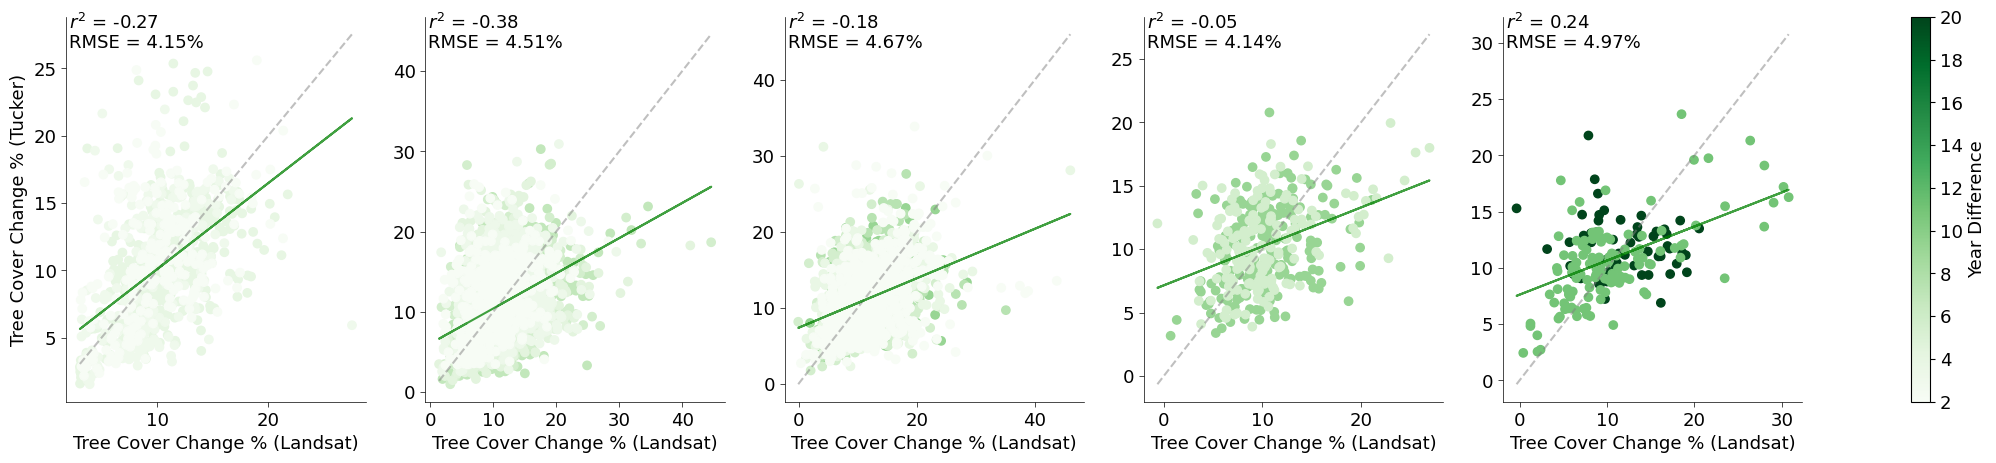

In [49]:
# calculate r2 of un-bias corrected
from sklearn.metrics import r2_score
# calculate rmse of un-bias corrected
from sklearn.metrics import mean_squared_error
#use bias to correct positive prediction


def plot_scatters(fig, ax, gdf, ax_index, vmin, vmax):

    bias = gdf["positive_change_mean"] - gdf["positive_trend_mean"]
    bias.mean()
    gdf["positive_trend_corrected"] = gdf["positive_trend_mean"] + bias.mean()


    # add a line of perfect fit
    ax[ax_index].plot([np.min(gdf["positive_trend_corrected"]*100), 
            np.max(gdf["positive_trend_corrected"]*100)], 
            [np.min(gdf["positive_trend_corrected"]*100), 
            np.max(gdf["positive_trend_corrected"]*100)],
            color='grey', alpha = 0.5, linestyle='--')

    # scatter plot with colour based on year difference
    sc = ax[ax_index].scatter(gdf["positive_trend_corrected"]*100,
                    gdf["positive_change_mean"]*100,
                    c = gdf["year_diff"],
                    cmap = 'Greens',
                    alpha = 1,
                    vmin=vmin,
                    vmax=vmax)

    m, b = np.polyfit(gdf["positive_trend_corrected"]*100, 
                    gdf["positive_change_mean"]*100, 1)

    ax[ax_index].plot(gdf["positive_trend_corrected"]*100, 
            m*gdf["positive_trend_corrected"]*100 + b, 
            color='green', alpha = 0.75)

    ax[ax_index].spines['top'].set_visible(False)
    ax[ax_index].spines['right'].set_visible(False)

    # change color of axes
    ax[ax_index].spines['bottom'].set_color('black')
    ax[ax_index].spines['left'].set_color('black')

    ax[ax_index].spines['bottom'].set_linewidth(0.5)
    ax[ax_index].spines['left'].set_linewidth(0.5)

    # change color of ticks and labels
    ax[ax_index].tick_params(axis='x', colors='black', width = 0.5, labelsize = 13)
    ax[ax_index].tick_params(axis='y', colors='black', width = 0.5, labelsize = 13)

    # add text to top left with superscript
    ax[ax_index].text(0.01, 0.97, f'$r^2$ = {r2_score(gdf["positive_trend_corrected"], gdf["positive_change_mean"]):.2f}',
                      transform=ax[ax_index].transAxes, fontsize=13)
    
    ax[ax_index].text(0.01, 0.92, f'RMSE = {mean_squared_error(gdf["positive_trend_corrected"]*100, gdf["positive_change_mean"]*100, squared=False):.2f}%',
                      transform=ax[ax_index].transAxes, fontsize=13)

    ax[ax_index].set_xlabel("Tree Cover Change % (Landsat)", fontsize=13)

    return fig, ax

fig, ax = plt.subplots(1, 5, figsize=(28, 5))
fig, ax = plot_scatters(fig, ax, gdf_filtered_2, 0, 2, 20)
fig, ax = plot_scatters(fig, ax, gdf_filtered_5, 1, 5, 20)
fig, ax = plot_scatters(fig, ax, gdf_filtered_10, 2, 10, 20)
fig, ax = plot_scatters(fig, ax, gdf_filtered_15, 3, 15, 20)
fig, ax = plot_scatters(fig, ax, gdf_filtered_18, 4, 18, 20)

cbar = plt.colorbar(ax[0].collections[0], ax=ax)
cbar.set_label('Year Difference', fontsize=13)
cbar.cmap.set_over('green')
cbar.set_ticklabels([f"{int(i)}" for i in cbar.get_ticks()], fontsize=13)

ax[0].set_ylabel("Tree Cover Change % (Tucker)", fontsize=13)
#plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/positive_change_comparison_5_v2.pdf", dpi = 1000)
plt.show()

In [6]:
gdf_filtered = gdf

/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_456141/1019260993.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels([f"{int(i)}" for i in cbar.get_ticks()])


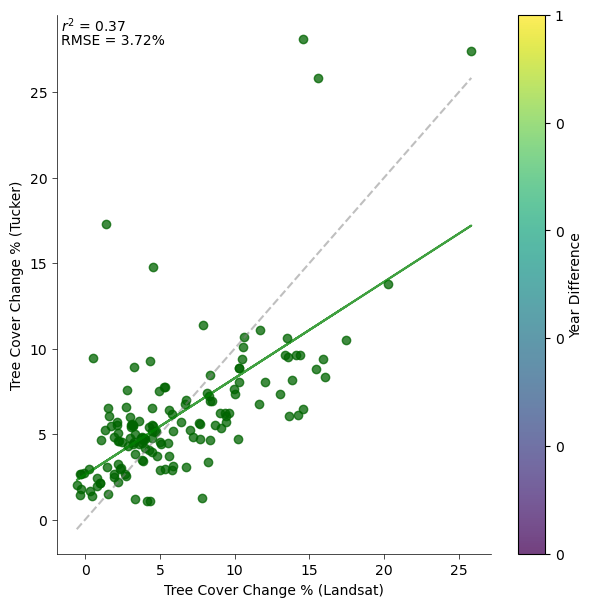

In [7]:
# calculate r2 of un-bias corrected
from sklearn.metrics import r2_score
# calculate rmse of un-bias corrected
from sklearn.metrics import mean_squared_error
#use bias to correct positive prediction

# calculate bias between positive prediction and positive observed
bias = gdf_filtered["positive_change_mean"] - gdf_filtered["positive_trend_mean"]
bias.mean()
gdf_filtered["positive_trend_corrected"] = gdf_filtered["positive_trend_mean"] + bias.mean()

fig, ax = plt.subplots(figsize=(7, 7))

# add a line of perfect fit
plt.plot([np.min(gdf_filtered["positive_trend_corrected"]*100), 
          np.max(gdf_filtered["positive_trend_corrected"]*100)], 
         [np.min(gdf_filtered["positive_trend_corrected"]*100), 
          np.max(gdf_filtered["positive_trend_corrected"]*100)],
         color='grey', alpha = 0.5, linestyle='--')

plt.scatter(gdf_filtered["positive_trend_corrected"]*100,
            gdf_filtered["positive_change_mean"]*100,
            c = "darkgreen", alpha=0.75)

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Year Difference')
cbar.cmap.set_over('green')
cbar.set_ticklabels([f"{int(i)}" for i in cbar.get_ticks()])

m, b = np.polyfit(gdf_filtered["positive_trend_corrected"]*100, 
                  gdf_filtered["positive_change_mean"]*100, 1)

plt.plot(gdf_filtered["positive_trend_corrected"]*100, 
         m*gdf_filtered["positive_trend_corrected"]*100 + b, 
         color='green', alpha = 0.75)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)

# add text to top left with superscript
plt.text(0.01, 0.97, f'$r^2$ = {r2_score(gdf_filtered["positive_trend_corrected"], gdf_filtered["positive_change_mean"]):.2f}', transform=ax.transAxes)
plt.text(0.01, 0.945, f'RMSE = {mean_squared_error(gdf_filtered["positive_trend_corrected"]*100, gdf_filtered["positive_change_mean"]*100, squared=False):.2f}%', transform=ax.transAxes)


plt.xlabel("Tree Cover Change % (Landsat)")
plt.ylabel("Tree Cover Change % (Tucker)")
plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/positive_change_comparison_year_diff_lt_3.png", dpi = 1000)
plt.show()

/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


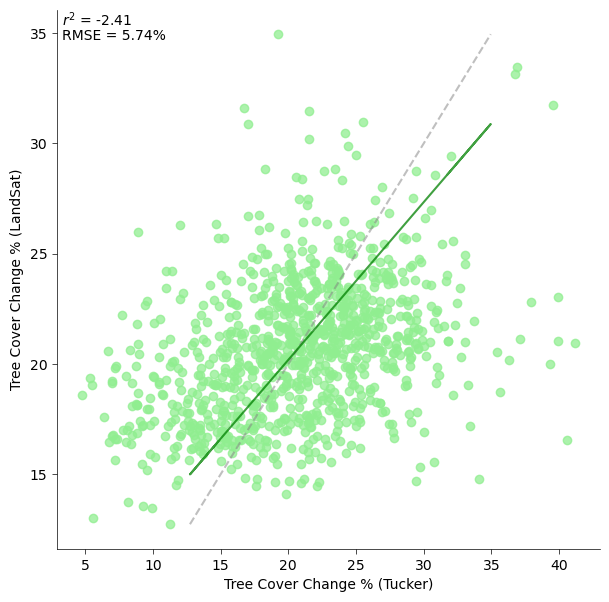

In [66]:
# calculate r2 of un-bias corrected
from sklearn.metrics import r2_score
# calculate rmse of un-bias corrected
from sklearn.metrics import mean_squared_error
#use bias to correct positive prediction

gdf_filtered["negative_trend_mean"] = gdf_filtered["negative_trend_mean"]*-1
gdf_filtered["negative_change_mean"] = gdf_filtered["negative_change_mean"]*-1

# calculate bias between positive prediction and positive observed
bias = gdf_filtered["negative_change_mean"] - gdf_filtered["negative_trend_mean"]
bias.mean()
gdf_filtered["negative_trend_corrected"] = gdf_filtered["negative_trend_mean"] + bias.mean()

fig, ax = plt.subplots(figsize=(7, 7))

# add a line of perfect fit
plt.plot([np.min(gdf_filtered["negative_trend_corrected"]*100), np.max(gdf_filtered["negative_trend_corrected"]*100)], [np.min(gdf_filtered["negative_trend_corrected"]*100), np.max(gdf_filtered["negative_trend_corrected"]*100)], color='grey', alpha = 0.5, linestyle='--')
plt.scatter(gdf_filtered["negative_change_mean"]*100, gdf_filtered["negative_trend_corrected"]*100, color='lightgreen', alpha=0.75)

m, b = np.polyfit(gdf_filtered["negative_trend_corrected"]*100, gdf_filtered["negative_change_mean"]*100, 1)
plt.plot(gdf_filtered["negative_trend_corrected"]*100, m*gdf_filtered["negative_trend_corrected"]*100 + b, color='green', alpha = 0.75)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)

# add text to top left with superscript
plt.text(0.01, 0.97, f'$r^2$ = {r2_score(gdf_filtered["negative_trend_corrected"], gdf_filtered["negative_change_mean"]):.2f}', transform=ax.transAxes)
plt.text(0.01, 0.945, f'RMSE = {mean_squared_error(gdf_filtered["negative_trend_corrected"]*100, gdf_filtered["negative_change_mean"]*100, squared=False):.2f}%', transform=ax.transAxes)


plt.xlabel("Tree Cover Change % (Tucker)")
plt.ylabel("Tree Cover Change % (LandSat)")
plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/negative_change_comparison_ls7.png", dpi = 1000)

In [ ]:
average_preds_perc = average_preds * 100
average_ys_perc = average_ys * 100

rmse = np.sqrt(np.mean((average_preds_perc - average_ys_perc) ** 2))

print("sklearn_r2 canopy", r2_score(average_ys_perc[:, 0], average_preds_perc[:, 0]))
print("RMSE: ", rmse)

canopy_r2 = val_89_results[-2].compute()
print("torch_r2", canopy_r2)

fig, ax = plt.subplots(figsize=(7, 7))

# add a line of perfect fit
plt.plot([0, np.max(average_ys_perc[:, 0])], [0, np.max(average_ys_perc[:, 0])], color='grey', alpha = 0.5, linestyle='--')
plt.scatter(gdf_filtered["positive_trend_mean"], gdf_filtered["positive_change_mean"], color='lightgreen', alpha=0.75)

# add a line of best fit
m, b = np.polyfit(average_ys_perc[:, 0], average_preds_perc[:, 0], 1)
plt.plot(average_ys_perc[:, 0], m*average_ys_perc[:, 0] + b, color='green', alpha = 0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)

# add text to top left with superscript
plt.text(0.01, 0.97, f"$r^2$ = {r2_score(average_ys_perc, average_preds_perc):.2f}", transform=ax.transAxes)
plt.text(0.01, 0.945, f"RMSE = {rmse:.2f}%", transform=ax.transAxes)

plt.xlabel("Tree Cover % (Tucker)")
plt.ylabel("Tree Cover % (LandSat-8/9)")
plt.show()

/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


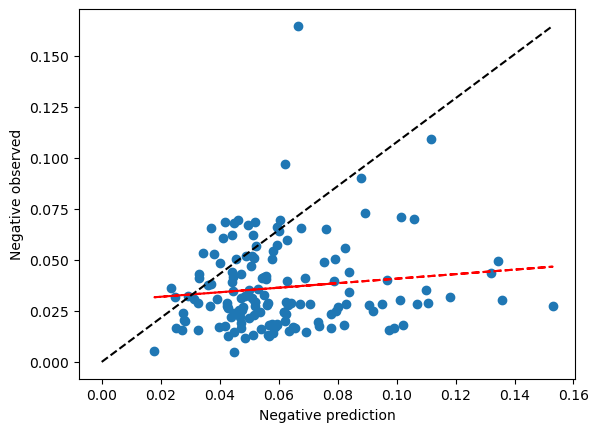

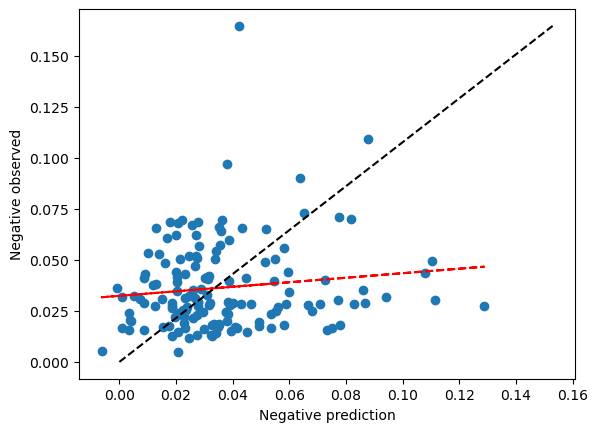

-1.535077391974513
0.03892117313913255
-0.5595443659355783
0.030527355062564505


In [19]:
# calculate r2 of un-bias corrected
from sklearn.metrics import r2_score
# calculate rmse of un-bias corrected
from sklearn.metrics import mean_squared_error

gdf_filtered["abs_negative_trend_mean"] = gdf_filtered["negative_trend_mean"].abs()
gdf_filtered["abs_negative_change_mean"] = gdf_filtered["negative_change_mean"].abs()

plt.scatter(gdf_filtered["abs_negative_trend_mean"], gdf_filtered["abs_negative_change_mean"])

# add trendline
z = np.polyfit(gdf_filtered["abs_negative_trend_mean"], gdf_filtered["abs_negative_change_mean"], 1)
p = np.poly1d(z)
plt.plot(gdf_filtered["abs_negative_trend_mean"],p(gdf_filtered["abs_negative_trend_mean"]),"r--")
#add 1 to 1 line
plt.plot([0,np.max(gdf_filtered["abs_negative_trend_mean"])],[0,np.max(gdf_filtered["abs_negative_change_mean"])], "k--")

plt.xlabel("Negative prediction")
plt.ylabel("Negative observed")
plt.show()

# calculate bias between positive prediction and positive observed
bias = gdf_filtered["abs_negative_change_mean"] - gdf_filtered["abs_negative_trend_mean"]
bias.mean()

#use bias to correct positive prediction
gdf_filtered["abs_negative_trend_corrected"] = gdf_filtered["abs_negative_trend_mean"] + bias.mean()

# recalculate r2
r2_score(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"])

# replot

plt.scatter(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"])

# add trendline
z = np.polyfit(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"], 1)
p = np.poly1d(z)
plt.plot(gdf_filtered["abs_negative_trend_corrected"],p(gdf_filtered["abs_negative_trend_corrected"]),"r--")
#add 1 to 1 line
plt.plot([0,np.max(gdf_filtered["abs_negative_trend_mean"])],[0,np.max(gdf_filtered["abs_negative_change_mean"])], "k--")


plt.xlabel("Negative prediction")
plt.ylabel("Negative observed")
plt.show()


print(r2_score(gdf_filtered["abs_negative_trend_mean"], gdf_filtered["abs_negative_change_mean"]))

print(mean_squared_error(gdf_filtered["abs_negative_trend_mean"], gdf_filtered["abs_negative_change_mean"], squared=False))

print(r2_score(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"]))

print(mean_squared_error(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"], squared=False))




In [112]:
import random 
import matplotlib.pyplot as plt
import numpy as np

results_filtered = [r for r in results if r["trend"].max() != 0]
sumpool = nn.AvgPool2d(10, stride = 2)

results_pooled = []

pos_trend = []
neg_trend = []
pos_change = []
neg_change = []
plot=False

for result in results_filtered:
    try:
        early = result["early"]
        late = result["late"]
        trend = result["trend"]
        change = result["change"]
        early_pooled = sumpool(torch.tensor(early).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        late_pooled = sumpool(torch.tensor(late).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        trend_pooled = sumpool(torch.tensor(trend).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        
        change_pooled = late_pooled - early_pooled
        
        #print(early.shape, late.shape, trend.shape)
        #print(early_pooled.shape, late_pooled.shape, trend_pooled.shape)
        
        results_dict = {"trend": trend_pooled, "early": early_pooled, "late": late_pooled, "change": change_pooled}
        results_pooled.append(results_dict)
        
        if plot:
            if np.sum(change_pooled) < -20000 or np.sum(trend_pooled) > 10000:
                
                print(np.mean(change_pooled), np.mean(trend_pooled))
                fig, ax = plt.subplots(2, 2, figsize=(10, 10))
                ax[0,0].imshow(change_pooled)
                ax[0,1].imshow(change)
                ax[1,0].imshow(trend_pooled)
                ax[1,1].imshow(trend)
                plt.show()
            
        pos_trend.append(np.sum(trend_pooled[trend_pooled > 0]))
        neg_trend.append(np.sum(trend_pooled[trend_pooled < 0]))
        pos_change.append(np.sum(change_pooled[change_pooled > 0]))
        neg_change.append(np.sum(change_pooled[change_pooled < 0]))
    except Exception as e:
        #print(e)
        continue
    
    
    

In [14]:
print(len(results_pooled))

plt.scatter(pos_trend, pos_change)
#line 
plt.plot(np.unique(pos_trend), np.poly1d(np.polyfit(pos_trend, pos_change, 1))(np.unique(pos_trend)), color="red")
plt.xlabel("predicted change")
plt.ylabel("actual change")

# calculate r2
from sklearn.metrics import r2_score
r2_score(pos_trend, pos_change)



NameError: name 'results_pooled' is not defined

-1.7843431287753542

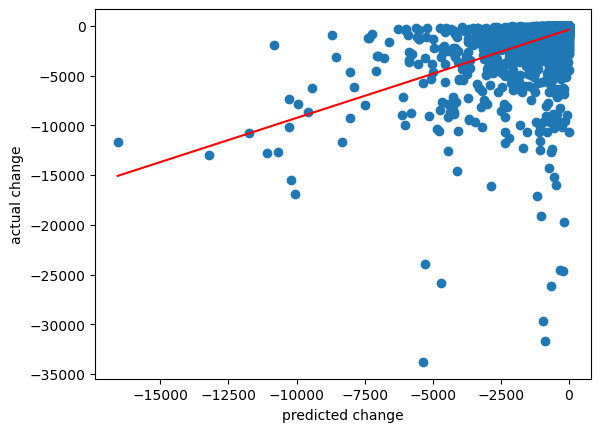

In [115]:
plt.scatter(neg_trend, neg_change)
#line 
plt.plot(np.unique(neg_trend), np.poly1d(np.polyfit(neg_trend, neg_change, 1))(np.unique(neg_trend)), color="red")
plt.xlabel("predicted change")
plt.ylabel("actual change")

# calculate r2
from sklearn.metrics import r2_score
r2_score(neg_trend, neg_change)

In [ ]:

# random sample 10 from results and plot trend vs change
sample = random.sample(results_filtered, 10)
for r in results_filtered[:100]:
    
    print(r["trend"].min(), r["trend"].max())
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(r["trend"])
    ax[0].set_title("Trend")
    ax[1].imshow(r["change"])
    ax[1].set_title("Change")
    plt.show()

In [13]:
print(len(results_filtered))
trend_sums = [r["trend"].sum() for r in results_filtered]
change_sums = [r["change"].sum() for r in results_filtered]

plt.scatter(trend_sums, change_sums)
#line 
plt.plot(np.unique(trend_sums), np.poly1d(np.polyfit(trend_sums, change_sums, 1))(np.unique(trend_sums)), color="red")
plt.xlabel("predicted change")
plt.ylabel("actual change")


NameError: name 'results_filtered' is not defined

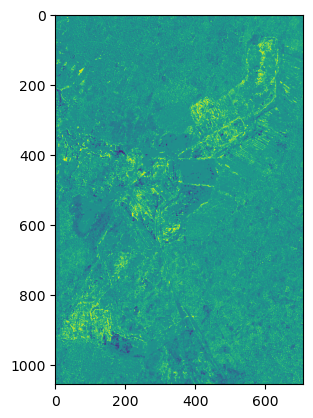

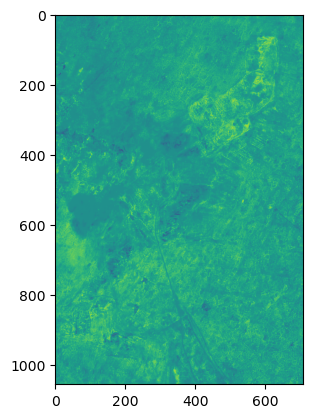

-1.0 1.0 -0.5643935 0.84001434
60265.203 0.080416545 107610.67 0.14359328


In [59]:
plt.imshow(change)
plt.show()
plt.imshow(trend_data, vmin=change.min(), vmax=change.max())
plt.show()
print(change.min(), change.max(), trend_data.min(), trend_data.max())
print(np.sum(change), np.mean(change), np.sum(trend_data), np.mean(trend_data))